# Introduction
    This project analyzes the U.S GDP Growth Rate based on a quarterly basis ranging from 2010-2023. The dataset used for this project is from the U.S. Bureau of Economic Analysis (BEA) with seasonlly adjusted annual rate (SAAR) of real GDP growth, in percent, and only has selcted quarters. Another note given about the data is that there are "dramatic values in 2020 Q2 and Q3 which reflect the COVID-19 pandemic shock and recovery." The three methods I will apply to analyze this dataset is least cublic spline interpolation, least squares linear regression, and polynomial fitting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Quarters - X Values
x = np.arange(1,21)

# GDP Growth - Y Values
y = np.array([
    1.7,0.1,2.3,2.7,1.7,
    5.0,3.0,1.5,3.5,1.8,
    1.3,2.5,3.1,-5.1,-28.1,
    33.8,6.3,-1.6,2.4,3.3
])

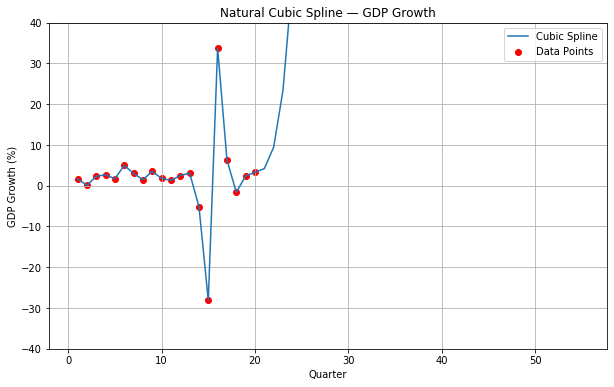

Linear Fit
MSE: 100.91791428571426
RSME: 10.045790874078271
R2: 0.0006880632067538528

Degree 4 Polynomial Fit
MSE: 99.3077379621237
RMSE: 9.965326786519531
R2: 0.016632392138784757


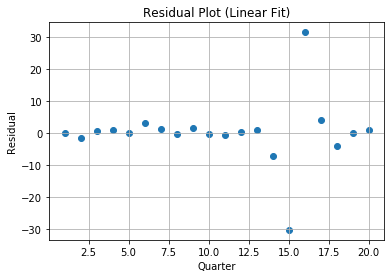

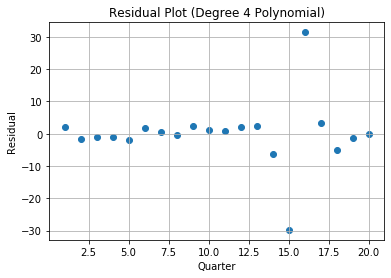

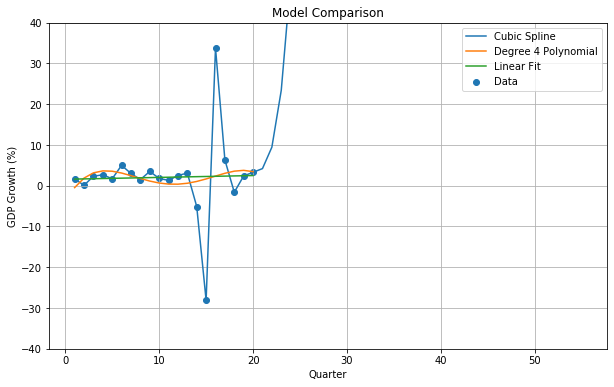


Linear Fit (No COVID Data)
Slope: -0.017336448598130803


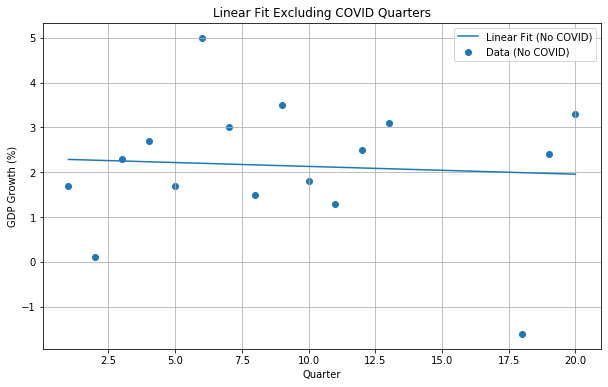

In [2]:
# Part A - Cublic Spline Interpolation

def setup_tridiagonal_matrix(x, y):
    
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i]) / h[i] - (y[i]-y[i-1]) / h[i-1]) #Right-hand side vector
        
    return A,B,C,D

def thomas_algorithm(a, b, c, d):
    
    n = len(b)
    
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
        
    return x

def evaluate_spline(x_data, y_data, M, x_query):

    n = len(x_data)
    h = np.diff(x_data) # step sizes
    
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

n = len(x)
A, B, C, D = setup_tridiagonal_matrix(x, y)
M_internal = thomas_algorithm(A,B,C,D)

M = np.zeros(n)
M[1:n-1] = M_internal

x_full = np.arange(1,56)
y_full = np.array([evaluate_spline(x, y, M, xi) for xi in x_full])

plt.figure(figsize=(10,6))
plt.plot(x_full, y_full, label="Cubic Spline")
plt.scatter(x, y, color='red', label="Data Points")
plt.title("Natural Cubic Spline — GDP Growth")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.ylim(-40,40) # Was not able to the point pass through -28.1 so asked Chat GPT how to fix issue
plt.legend()
plt.grid(True)
plt.show()


# Part B - Polynomial & Least Squares Comparison

def evaluate(y_true,y_pred):     
    mse = np.mean((y_true - y_pred)**2)     
    ss_total = np.sum((y_true - np.mean(y_true))**2)     
    ss_res = np.sum((y_true - y_pred)**2)     
    r2 = 1 - (ss_res/ss_total)     
    return mse,r2

A = np.vstack([x, np.ones(len(x))]).T 

ATA = np.dot(A.T,A)
ATy = np.dot(A.T,y)

coefficients = np.linalg.solve(ATA,ATy)

m = coefficients[0]
c = coefficients[1]

y_linear = m*x + c 

degree = 4 
V = np.vander(x, N=degree+1, increasing=True) 
VT_V = np.dot(V.T,V) 
VT_y = np.dot(V.T,y)
    
coefficients = np.linalg.solve(VT_V,VT_y) 
y_vander = V @ coefficients 

mse_linear,r2_linear = evaluate(y,y_linear)
mse_poly,r2_poly = evaluate(y,y_vander) 

mse_vander = np.mean((y - y_vander)**2)
ss_total = np.sum((y - np.mean(y))**2) 
ss_res = np.sum((y - y_vander)**2) 
r2_vander = 1 - (ss_res/ss_total) 

# Asked ChatGPT on how to create residuals for this assignment based on what I previously had built in from HW
rmse_linear = np.sqrt(mse_linear)
rmse_poly = np.sqrt(mse_poly)

print("Linear Fit") 
print("MSE:",mse_linear) 
print("RSME:",rmse_linear)
print("R2:",r2_linear) 

print("\nDegree 4 Polynomial Fit") 
print("MSE:",mse_poly) 
print("RMSE:",rmse_poly)
print("R2:",r2_poly) 

residuals_linear = y -y_linear
residuals_poly = y - y_vander

plt.figure()
plt.scatter(x,residuals_linear)
plt.title("Residual Plot (Linear Fit)")
plt.xlabel("Quarter")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(x,residuals_poly)
plt.title("Residual Plot (Degree 4 Polynomial)")
plt.xlabel("Quarter")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(x, y, label="Data")
plt.plot(x_full, y_full, label="Cubic Spline")
plt.plot(x, y_vander, label="Degree 4 Polynomial")
plt.plot(x, y_linear, label="Linear Fit")
plt.title("Model Comparison")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.ylim(-40,40)
plt.legend()
plt.grid(True)
plt.show()

x_covid = np.delete(x, np.arange(13, 17))
y_covid = np.delete(y, np.arange(13, 17))

A_c = np.vstack([x_covid, np.ones(len(x_covid))]).T
ATA_c = A_c.T @ A_c
ATy_c = A_c.T @ y_covid

coeffs_c = np.linalg.solve(ATA_c, ATy_c)

m_c, c_c = coeffs_c

print("\nLinear Fit (No COVID Data)")
print("Slope:", m_c)

# Plot
y_c_line = m_c * x_covid + c_c

plt.figure(figsize=(10,6))
plt.scatter(x_covid, y_covid, label="Data (No COVID)")
plt.plot(x_covid, y_c_line, label="Linear Fit (No COVID)")
plt.title("Linear Fit Excluding COVID Quarters")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.show()

# Ran my code through ChatGPT like usual to ensure no code errors were missed and matches expectations of project

# Part A Questions

## Question 1
    There are n-2 unknowns. There are three continuity conditions interpolation (C0), first derivative continuity (C1), and second derivative continuity (C2). The bounary conditions is 0.  

## Question 2
    The spline was evaluated at all 55 points in the dataset (2010 Q1 through 2023 Q4). Observing the graph plotted above, the interpolant is visually smooth and reasonable. There is only one large jump, which is likely due to the drastic change in values due to COVID-19 (which was noted in the dataset). 

## Question 3
    The Runge phenomenon is when large oscillations are produced by high degree polynomial interpolation. The trade-off between exact interpolation and numerical stability for datasets with extreme outliers is very crucial. On one end, exact interpolation ensures that all data points are accounted, however, on the other end this will cause a large outlier in data which leads to numerical instability. Smoothing splines would be preffered here as this method "smooths" out the data by minimizing data.

# Part B Questions

## Question 1
    Looking at the model comparisson graph, it clearly shows how different the plots are when using cublic spline interpolation vs a degree 4 polynomial. The cublic spline passes through all data points given, which makes it a better method for producing specific data points. The degree 4 polynomial is an approximation as it minimizes the overall error which makes a smoother curve. Through this minimization, the degree 4 polynomial is better at capturing the overall trend of the data. The main two trade offs between the two is that one accounts for all exact data while the other "averages" and secondly one can show a simple trend while the other can drastically change due to various changes in data.
    
## Question 2
    The slope of this line is very small which explains the GDP growth does not go up or down consistently. Due to this a linear model is not the best way to decribe the data as it assumes the data is increasing or decreasing at a constant rate. GDP growth is alwasy changing by various factors and therefore will never have a specific consistent "trend."

# Part C Questions

## Question 1
    For a policy maker who needs to estimate GDP growth for a quarter between two known points (interpolation), I would recommend cublic spline. The first arguement I would make about using this method, is that cubic spline has way more accuracy. Cublic spline moves through every exact point where as polynomial fitting creates a trend off the points. Taking into account every point is crucial to accuracy. The second arguement I would make is that cubic spline is much smoother as it has three continuity conditions. The third and last arguement I would make is that it is less sensitive to outliers. Since polynomial fitting is an "average trend" the outliers can greatly change the curve, which can make it appear like there was a great change in more than one point.
    
# Big O Analysis
    Big O notation is "a mathematical notation used to describe the time complexity or space complexity of an algorithm as a function of the input size n;" or in simpler terms, it "evaluates the efficiency of an algorithm based on its growth rate as size increases." First, looking at the cubic spline interpolation, this method is classified as an O(n) as it is linear time as the runtime grows linearly with the input size n. Next, looking at the least squares linear regression, this method is also classified as O(n) as it solves simple equations and there is only one loop over the data. Finally, looking at polynomial fitting, this method is also classified as an O(n) (almost) as the matrix approximately acts like a linear function. Since all three methods have the same Big O notation, I would still not change my recommendation of cubic spline interpolation. Since they are all the same, Big O notation should not be a factor in deciding what method to go with.

# Conclusion
    In conclusion, the method that worked best for exact interpolation and accuracy was cubic spline and polynomial fitting worked best for trend analysis. Cubic spline interpolation takes into account all points of the data given which makes it more accurate. However, through this project I learned that it truly depends on the project for which method is "best". While cubic spline is accurate, it's limitation is that it can not provide an average trend analysis. On the other end, polynomial fitting is better for trend analysis as it averages out the data points. While some projects this is a positive and sometimes the goal, this method was limited to helping this project as it did not show all plotted points, including the outliers. 